<a href="https://colab.research.google.com/github/Pranayshukla0610/Data-Science-Projects/blob/main/Fashion_MNIST_CNN_Deep_Learning_Mastery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    AveragePooling2D,
    GlobalAveragePooling2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization,
    LeakyReLU
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
(X_train, y_train), (X_test,y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
class_names = [
    'T-shirt',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

In [4]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


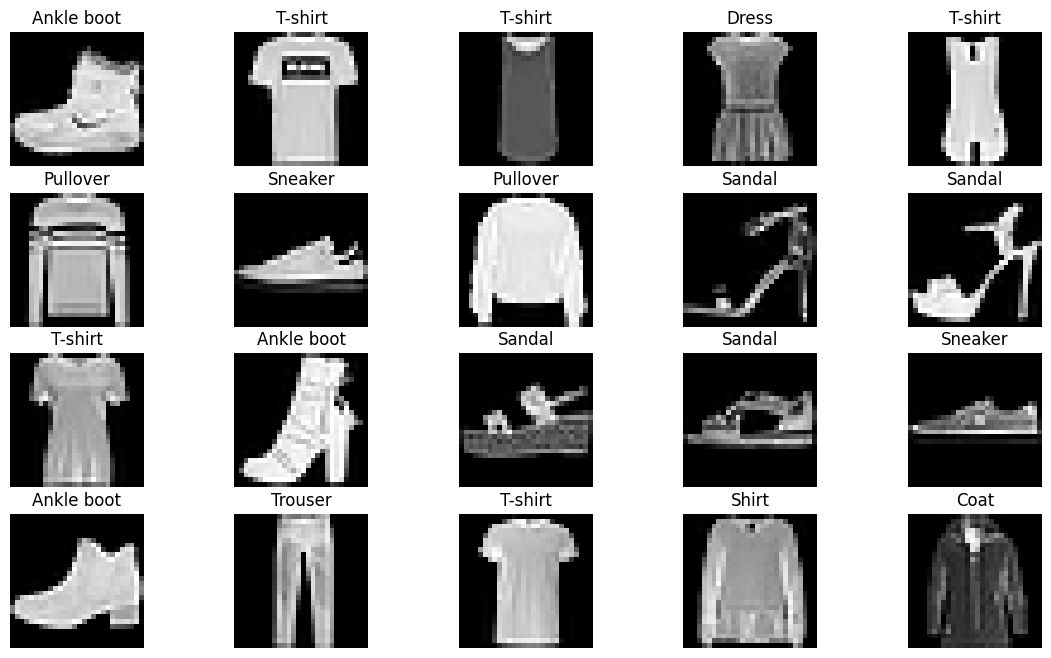

In [5]:
plt.figure(figsize=(14,8))

for i in range(20):
  plt.subplot(4,5,i+1)
  plt.imshow(X_train[i],cmap='gray')
  plt.title(class_names[y_train[i]])
  plt.axis('off')

plt.show()

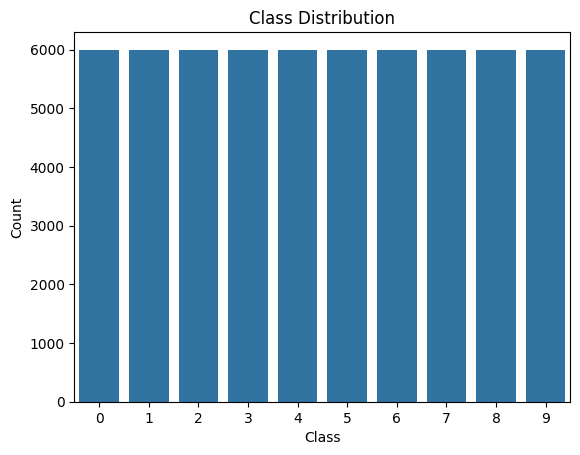

In [6]:
sns.countplot(x=y_train)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

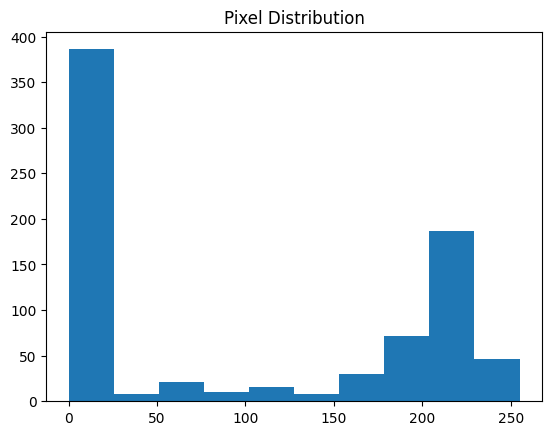

In [7]:
plt.hist(X_train[0].flatten())
plt.title('Pixel Distribution')
plt.show()

In [8]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [9]:
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

In [10]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [11]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        padding='same',
        activation='relu',
        input_shape=(28,28,1)
    )
)

model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10,activation='softmax'))

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,759,370 (18.16 MB)

 Trainable params: 4,759,050 (18.15 MB)

 Non-trainable params: 320 (1.25 KB)

In [13]:
model.compile(
    optimizer='adam',
    loss = 'categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(X_train)

In [15]:
history = model.fit(
    datagen.flow(X_train,y_train,batch_size=32),
    epochs=10,
    validation_data=(X_test,y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 272s 144ms/step - accuracy: 0.6981 - loss: 0.8721 - val_accuracy: 0.8102 - val_loss: 0.5367
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 251s 134ms/step - accuracy: 0.7765 - loss: 0.5987 - val_accuracy: 0.8370 - val_loss: 0.4922
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 266s 136ms/step - accuracy: 0.8073 - loss: 0.5243 - val_accuracy: 0.8664 - val_loss: 0.3653
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 257s 137ms/step - accuracy: 0.8225 - loss: 0.4826 - val_accuracy: 0.7808 - val_loss: 0.9104
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 268s 143ms/step - accuracy: 0.8341 - loss: 0.4580 - val_accuracy: 0.8802 - val_loss: 0.3313
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 262s 140ms/step - accuracy: 0.8418 - loss: 0.4343 - val_accuracy: 0.8822 - val_loss: 0.3194
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 267s 143ms/step - accuracy: 0.8490 - loss: 0.4137 - val_accuracy: 0.8824 - val_loss: 0.3295
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 266s 142ms/step - ac

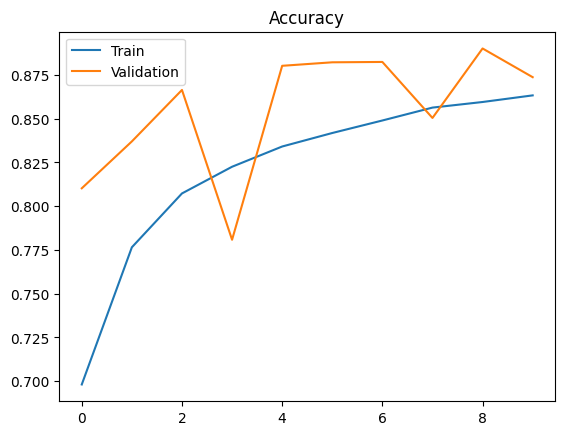

In [16]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Accuracy')
plt.legend(['Train','Validation'])
plt.show()

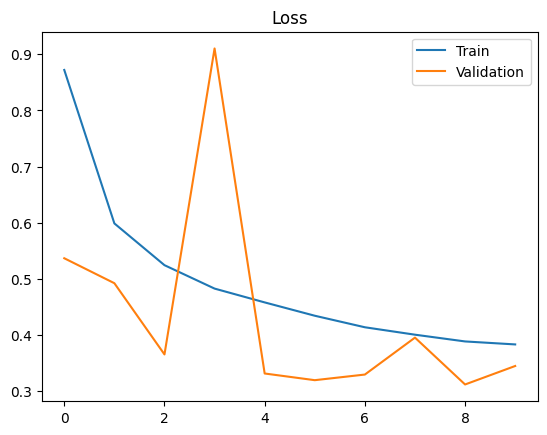

In [17]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Loss')
plt.legend(['Train','Validation'])
plt.show()

In [18]:
predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

true_labels = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step


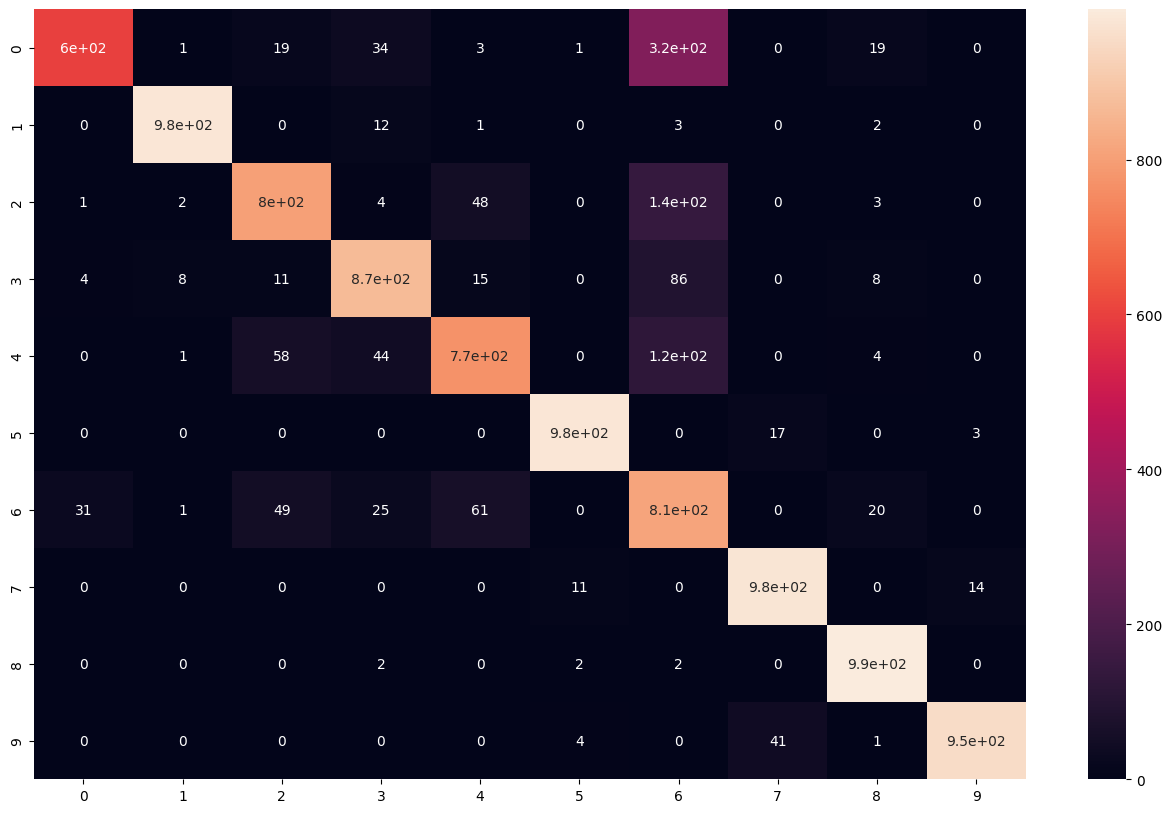

In [19]:
cm = confusion_matrix(
    true_labels,
    predicted_labels
)

plt.figure(figsize=(16,10))
sns.heatmap(cm,annot=True)
plt.show()

In [20]:
print(classification_report(
    true_labels,
    predicted_labels
))

              precision    recall  f1-score   support

           0       0.94      0.60      0.73      1000
           1       0.99      0.98      0.98      1000
           2       0.85      0.80      0.83      1000
           3       0.88      0.87      0.87      1000
           4       0.86      0.77      0.81      1000
           5       0.98      0.98      0.98      1000
           6       0.55      0.81      0.65      1000
           7       0.94      0.97      0.96      1000
           8       0.95      0.99      0.97      1000
           9       0.98      0.95      0.97      1000

    accuracy                           0.87     10000
   macro avg       0.89      0.87      0.88     10000
weighted avg       0.89      0.87      0.88     10000



In [21]:
from tensorflow.keras.applications import ResNet50

model.save("fashion_mnist_cnn.h5")

In [22]:
from tensorflow.keras.models import load_model

loaded_model = load_model(
    "fashion_mnist_cnn.h5"
)